# Chapter 08 — SABR Volatility Surface Calibration

# 1. Introduction
## SABR Smile Modelling for Swaptions

This chapter extends the volatility modelling framework developed in Chapter 07.

In Chapter 07, we built:

```text
Market Swaption Quotes
        ↓
Implied Vol Surface
        ↓
Black Price Surface
        ↓
Dupire Local Vol Surface
```

In this chapter, we build:

```text
Market Swaption Quotes
        ↓
Market Smile Slices
        ↓
SABR Calibration
        ↓
SABR Fitted Vol Surface
        ↓
Swaption Pricing with SABR Vol
```

## Why SABR?

Dupire local volatility can reproduce vanilla option prices, but it is numerically fragile because it requires derivatives of option prices.

SABR is widely used in interest rate markets because it provides:

- a parametric volatility smile
- intuitive parameters
- stable calibration
- realistic skew behaviour
- market-standard swaption smile fitting

This chapter focuses on calibrating SABR to swaption Black implied volatility quotes.

---

# 2. Import Libraries

In [18]:
import sys
import os

# Chapter 08 python files
sys.path.append("../python")

# Reuse previous chapter components
sys.path.append("../../06_black_swaption_pricing/python")
sys.path.append("../../07_local_volatility_and_dupire/python")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from market_data import (
    load_curve_data,
    load_raw_swaption_quotes,
    clean_swaption_quotes,
    get_quotes_for_expiry
)

from sabr_model import (
    hagan_sabr_black_vol,
    sabr_vol_vector
)

from sabr_calibration import (
    calibrate_sabr_slice
)

from sabr_surface import (
    SABRSurface
)

from sabr_pricing import (
    price_swaption_with_sabr
)

from diagnostics import (
    print_calibration_summary,
    compare_market_and_model,
    calibration_error_stats
)

from plotting import (
    plot_sabr_fit,
    plot_parameter_term_structure,
    plot_sabr_surface,
    plot_market_vol_surface,
    plot_sabr_residual_surface
)

plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


---
# 3. SABR Model Intuition

The SABR model describes the joint dynamics of a forward rate and its stochastic volatility.

The SABR dynamics are:

$$
dF_t = \alpha_t F_t^\beta dW_t^{(1)}
$$

$$
d\alpha_t = \nu \alpha_t dW_t^{(2)}
$$

with correlation:

$$
dW_t^{(1)} dW_t^{(2)} = \rho dt
$$

## Parameters

| Parameter | Meaning |
|---|---|
| $\alpha$ | Volatility level |
| $\beta$ | Elasticity of forward rate |
| $\rho$ | Correlation between rate and vol shocks |
| $\nu$ | Volatility of volatility |

## Financial Interpretation

- $\alpha$ controls the overall volatility level
- $\beta$ controls how volatility scales with the forward rate
- $\rho$ controls smile skew
- $\nu$ controls smile curvature

This is why SABR is useful for swaption smiles.

A detailed introduction to the SABR model can be seen from <http://laurent.jeanpaul.free.fr/Enseignement/The%20SABR%20Model.pdf>

---

# 4. Hagan SABR Black Volatility Approximation

In practice, SABR is usually calibrated using Hagan's closed-form approximation for Black implied volatility.

For each strike \(K\), the model produces:

$$
\sigma_{SABR}(F,K,T;\alpha,\beta,\rho,\nu)
$$

We then choose parameters so that:

$$
\sigma_{SABR}(K)
\approx
\sigma_{market}(K)
$$

for all quoted strikes.

This chapter uses fixed \(\beta\), usually:

$$
\beta = 0.5
$$

and calibrates:

$$
(\alpha,\rho,\nu)
$$

for each expiry slice.

---

# 5. Load Market Data

In [2]:
curve = load_curve_data(
    "../data/curve_data.csv"
)

raw_quotes = load_raw_swaption_quotes(
    "../data/swaption_vol_surface.csv"
)

clean_quotes = clean_swaption_quotes(
    raw_quotes,
    curve,
    target_tenor=5.0
)

clean_quotes.head()

,expiry,tenor,forward_swap_rate,strike_shift_bp,strike,black_vol
0,1.0,5.0,0.044682,-300.0,0.014682,0.335
1,1.0,5.0,0.044682,-250.0,0.019682,0.300
2,1.0,5.0,0.044682,-200.0,0.024682,0.275
3,1.0,5.0,0.044682,-150.0,0.029682,0.255
4,1.0,5.0,0.044682,-100.0,0.034682,0.240


In [3]:
# ============================================================
#  Inspect Cleaned Quotes
# ============================================================

print(clean_quotes.head(20))

print("\nAvailable expiries:")
print(sorted(clean_quotes["expiry"].unique()))

    expiry  tenor  forward_swap_rate  strike_shift_bp    strike  black_vol
0      1.0    5.0           0.044682           -300.0  0.014682      0.335
1      1.0    5.0           0.044682           -250.0  0.019682      0.300
2      1.0    5.0           0.044682           -200.0  0.024682      0.275
3      1.0    5.0           0.044682           -150.0  0.029682      0.255
4      1.0    5.0           0.044682           -100.0  0.034682      0.240
5      1.0    5.0           0.044682            -50.0  0.039682      0.225
6      1.0    5.0           0.044682              0.0  0.044682      0.210
7      1.0    5.0           0.044682             50.0  0.049682      0.220
8      1.0    5.0           0.044682            100.0  0.054682      0.230
9      1.0    5.0           0.044682            150.0  0.059682      0.245
10     1.0    5.0           0.044682            200.0  0.064682      0.265
11     1.0    5.0           0.044682            250.0  0.069682      0.290
12     1.0    5.0        

---
# 6. Market Smile Slice

We first inspect one expiry slice.

A swaption smile slice is:

$$
\sigma_{market}(K)
$$

for fixed expiry \(T\) and fixed underlying swap tenor.

For example, for a 5Y expiry and 5Y underlying swap tenor:

```text
5Y × 5Y swaption smile
```

This is the standard object SABR calibrates to.

## 6.1 Extract One Smile Slice - expiry = 5.0

In [4]:
expiry = 5.0

forward, strikes, market_vols = get_quotes_for_expiry(
    clean_quotes,
    expiry
)

print("Expiry:", expiry)
print("Forward swap rate:", forward)
print("Strikes:")
print(strikes)
print("Market vols:")
print(market_vols)

Expiry: 5.0
Forward swap rate: 0.04277422297887707
Strikes:
[0.01277422 0.01777422 0.02277422 0.02777422 0.03277422 0.03777422
 0.04277422 0.04777422 0.05277422 0.05777422 0.06277422 0.06777422
 0.07277422]
Market vols:
[0.38  0.345 0.32  0.3   0.285 0.27  0.255 0.265 0.275 0.29  0.31  0.335
 0.365]


## 6.2 Plot Market Smile Slice

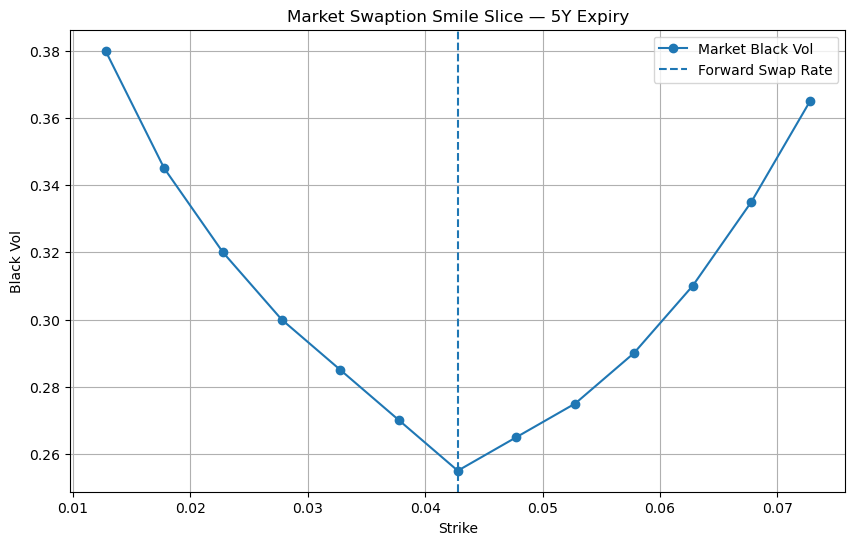

In [5]:
plt.figure()

plt.plot(
    strikes,
    market_vols,
    marker="o",
    label="Market Black Vol"
)

plt.axvline(
    forward,
    linestyle="--",
    label="Forward Swap Rate"
)

plt.title("Market Swaption Smile Slice — 5Y Expiry")
plt.xlabel("Strike")
plt.ylabel("Black Vol")
plt.grid()
plt.legend()
plt.show()

---
# 7. Calibrating One SABR Smile Slice

We now calibrate SABR to one expiry.

The objective function is:

$$
\min_{\alpha,\rho,\nu}
\sum_i
\left(
\sigma_{SABR}(K_i)
-
\sigma_{market}(K_i)
\right)^2
$$

with fixed:

$$
\beta = 0.5
$$

The calibration returns:

- $\alpha$
- $\rho$
- $\nu$
- fitted vols
- calibration RMSE

## 7.1 Calibrate One SABR Slice

In [6]:

result = calibrate_sabr_slice(
    forward=forward,
    strikes=strikes,
    expiry=expiry,
    market_vols=market_vols,
    beta=0.5
)

print("Calibration success:", result["success"])
print("alpha:", result["alpha"])
print("beta :", result["beta"])
print("rho  :", result["rho"])
print("nu   :", result["nu"])
print("RMSE :", result["rmse"])

Calibration success: True
alpha: 0.050596953381791536
beta : 0.5
rho  : 0.4633251043965504
nu   : 0.5304740478878252
RMSE : 0.017101514728797482


## 7.2 Compare Market and SABR Fitted Vols

In [7]:
compare_market_and_model(
    result
)

stats = calibration_error_stats(
    result
)

print("\nError stats:")
print(stats)


Strike | Market Vol | SABR Vol | Error
0.012774 | 0.380000 | 0.402200 | 0.022200
0.017774 | 0.345000 | 0.344124 | -0.000876
0.022774 | 0.320000 | 0.305311 | -0.014689
0.027774 | 0.300000 | 0.281071 | -0.018929
0.032774 | 0.285000 | 0.269549 | -0.015451
0.037774 | 0.270000 | 0.268420 | -0.001580
0.042774 | 0.255000 | 0.274048 | 0.019048
0.047774 | 0.265000 | 0.283016 | 0.018016
0.052774 | 0.275000 | 0.293171 | 0.018171
0.057774 | 0.290000 | 0.303430 | 0.013430
0.062774 | 0.310000 | 0.313316 | 0.003316
0.067774 | 0.335000 | 0.322643 | -0.012357
0.072774 | 0.365000 | 0.331363 | -0.033637

Error stats:
{'mean_error': np.float64(-0.0002567619817059629), 'max_abs_error': np.float64(0.03363653290071694), 'rmse': np.float64(0.017101514728797482)}


## 7.3 Plot SABR Fit for One Expiry

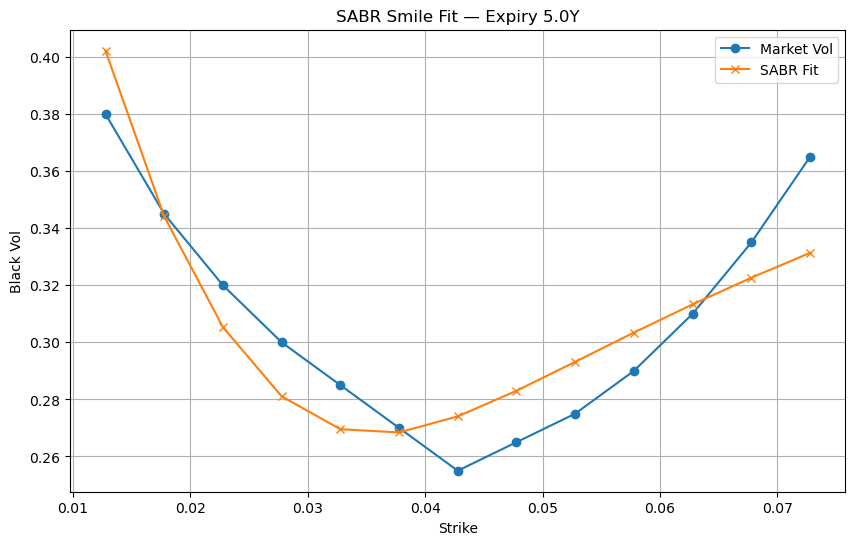

In [8]:
plot_sabr_fit(
    strikes=result["strikes"],
    market_vols=result["market_vols"],
    fitted_vols=result["fitted_vols"],
    expiry=expiry
)

---
# 8. Interpreting SABR Parameters

The calibrated parameters have financial meaning.

## $\alpha$ - Alpha

$\alpha$ controls the general level of volatility.

Higher $\alpha$ means the entire smile shifts upward.

## $\rho$ - Rho

$\rho$ controls skew.

If $\rho < 0$, volatility tends to be higher on the low-strike side.

This is common in many rates markets where receiver-side protection can be expensive.

## $\nu$ - Nu

$\nu$ controls curvature.

Higher $\nu$ means a more curved smile with fatter wings.

## Important FO Insight

SABR is useful because its parameters are interpretable.

This is one reason SABR remains widely used in interest rate volatility markets.

---
# 9. Calibrating the Full SABR Surface

We now calibrate SABR independently for every expiry.

For each expiry:

```text
market smile slice
        ↓
SABR calibration
        ↓
alpha, beta, rho, nu
```

The final output is a SABR parameter term structure:

```text
expiry → alpha
expiry → rho
expiry → nu
```

This is not yet a fully interpolated SABR cube, but it is the core calibration framework.

## 9.1 Calibrate Full SABR Surface

In [9]:
sabr_surface = SABRSurface(
    clean_quotes,
    beta=0.5
)

parameter_table = sabr_surface.calibrate()

print_calibration_summary(
    sabr_surface
)


SABR Calibration Summary
   expiry   forward     alpha  beta       rho        nu      rmse  success
0     1.0  0.044682  0.046284   0.5  0.417642  0.601792  0.015249     True
1     2.0  0.043953  0.048005   0.5  0.432195  0.578012  0.015868     True
2     3.0  0.043438  0.048812   0.5  0.443693  0.558401  0.016331     True
3     4.0  0.043059  0.049686   0.5  0.453928  0.543008  0.016738     True
4     5.0  0.042774  0.050555   0.5  0.464657  0.532089  0.017103     True
5     7.0  0.042402  0.051598   0.5  0.478361  0.509960  0.017654     True
6    10.0  0.042143  0.052009   0.5  0.494284  0.487059  0.018200     True
7    15.0  0.042148  0.051498   0.5  0.509222  0.461729  0.018665     True
8    20.0  0.042043  0.050695   0.5  0.523050  0.440011  0.019088     True
9    30.0  0.042648  0.048966   0.5  0.530026  0.417653  0.019235     True

Average RMSE:
0.017413290740237335


## 9.2 Display Parameter Table

In [10]:
parameter_table

,expiry,forward,alpha,beta,rho,nu,rmse,success
0,1.0,0.044682,0.046284,0.5,0.417642,0.601792,0.015249,True
1,2.0,0.043953,0.048005,0.5,0.432195,0.578012,0.015868,True
2,3.0,0.043438,0.048812,0.5,0.443693,0.558401,0.016331,True
3,4.0,0.043059,0.049686,0.5,0.453928,0.543008,0.016738,True
4,5.0,0.042774,0.050555,0.5,0.464657,0.532089,0.017103,True
5,7.0,0.042402,0.051598,0.5,0.478361,0.509960,0.017654,True
6,10.0,0.042143,0.052009,0.5,0.494284,0.487059,0.018200,True
7,15.0,0.042148,0.051498,0.5,0.509222,0.461729,0.018665,True
8,20.0,0.042043,0.050695,0.5,0.523050,0.440011,0.019088,True
9,30.0,0.042648,0.048966,0.5,0.530026,0.417653,0.019235,True


## 9.3 Plot SABR Parameter Term Structures

After warm-start calibration and tighter parameter bounds, the SABR
parameter term structures become much smoother. The decreasing nu
suggests that long-expiry smiles require less volatility-of-volatility,
while the gradual movement in rho reflects changing skew across expiries.
Alpha is not required to be monotonic because it interacts with beta,
rho, nu, and the forward swap rate in the SABR ATM approximation.

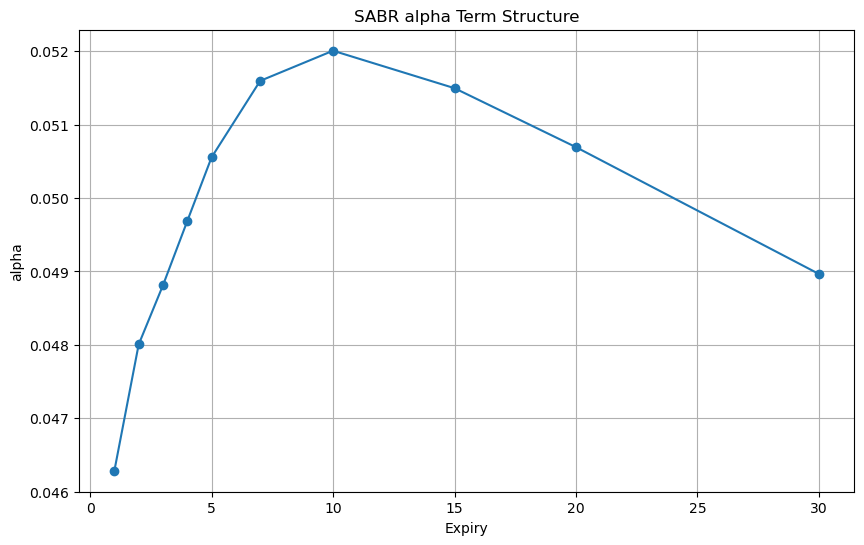

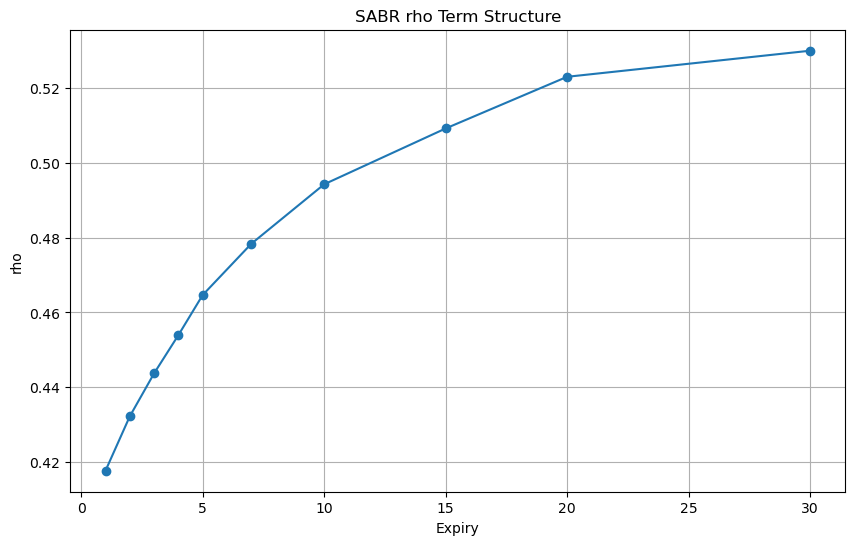

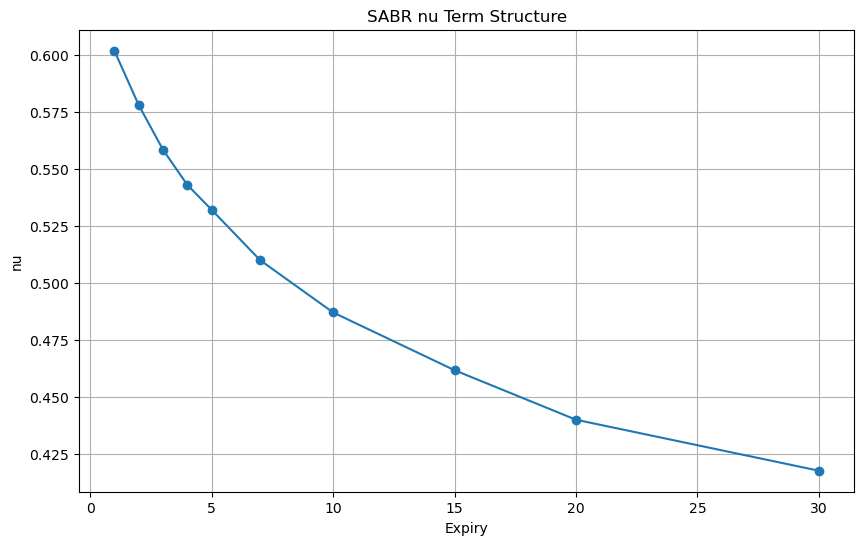

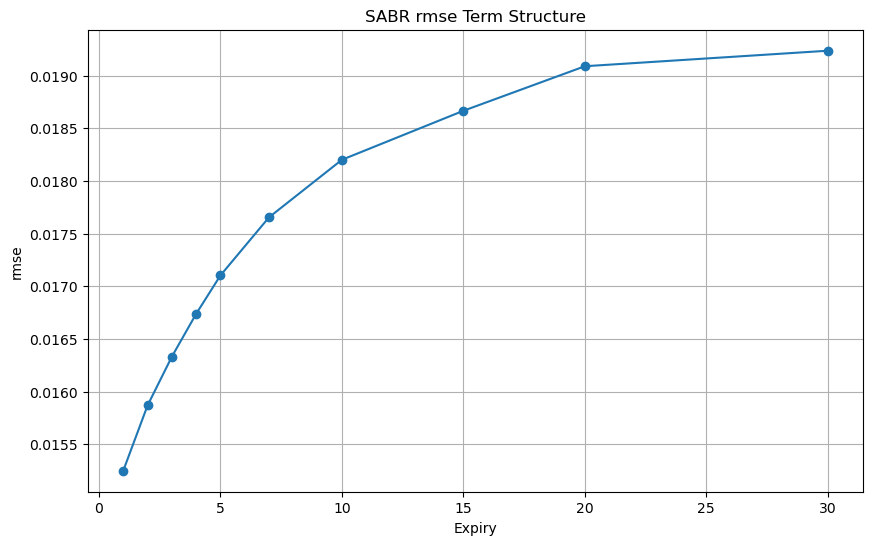

In [11]:
plot_parameter_term_structure(
    parameter_table
)

## 9.4 Practical Calibration Note: Alpha-Only Updates

In practice, SABR parameters are not always recalibrated with the same frequency.

A common workflow is:

- $\beta$ is fixed by convention
- $\rho$ and $\nu$ are updated less frequently
- $\alpha$ is updated more frequently to match the current ATM volatility level

This is because $\alpha$ mostly controls the volatility level, while $\rho$ controls skew and $\nu$ controls smile curvature.

Therefore, for intraday or daily marking, desks may perform an alpha-only update while keeping the structural smile parameters fixed.

---
# 10. SABR Fitted Vol Surface

After calibration, we can generate fitted volatilities for each expiry and strike.

This gives a model-implied volatility surface:

$$
\sigma_{SABR}(T,K)
$$

which should closely match the market implied volatility surface:

$$
\sigma_{market}(T,K)
$$

A good SABR calibration should reproduce:

- ATM volatility level
- skew
- smile curvature
- wing behaviour

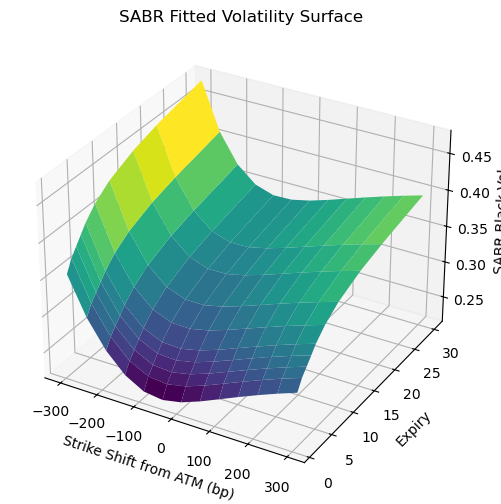

In [12]:
plot_sabr_surface(
    clean_quotes,
    sabr_surface
)

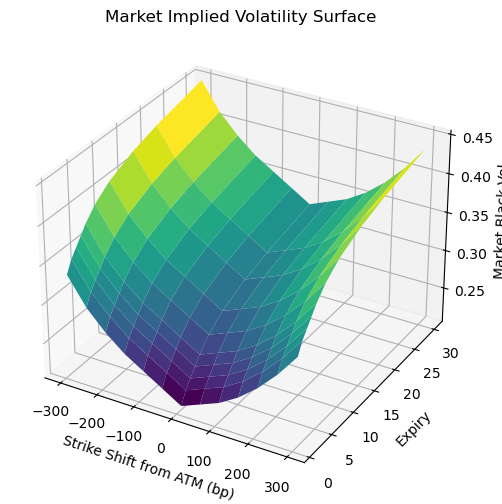

In [13]:
plot_market_vol_surface(
    clean_quotes
)

---
# 11. SABR vs Dupire

Chapter 07 used Dupire local volatility.

Chapter 08 uses SABR stochastic volatility.

They solve related but different problems.

## Dupire

Dupire constructs:

$$
\sigma_{loc}(T,K)
$$

from derivatives of option prices.

Strength:

- can reproduce vanilla option surface exactly

Weakness:

- numerically fragile
- sensitive to noisy data
- derivatives amplify noise

## SABR

SABR constructs:

$$
\sigma_{SABR}(F,K,T)
$$

from a parametric stochastic volatility model.

Strength:

- stable calibration
- interpretable parameters
- realistic skew and smile shape

Weakness:

- approximate formula
- may not perfectly fit every quote
- requires parameter choices such as \(\beta\)


## Quant Perspective

In real rates markets, SABR is often preferred for smile modelling because it provides stable, intuitive and tradable parameters.

---
# 12. Pricing a Swaption with SABR Volatility

Once SABR is calibrated, we can use it for pricing.

The workflow is:

```text
Expiry, Tenor, Strike
        ↓
Build forward-starting swap
        ↓
Compute forward swap rate
        ↓
Compute SABR Black vol
        ↓
Price with BlackSwaption
```

This directly reuses the Chapter 06 Black swaption pricer.

In [20]:
pricing_expiry = 5.0
pricing_tenor = 5.0

alpha, beta, rho, nu = sabr_surface.get_params(
    pricing_expiry
)

pricing_strike = forward

pricing_result = price_swaption_with_sabr(
    curve=curve,
    expiry=pricing_expiry,
    tenor=pricing_tenor,
    strike=pricing_strike,
    notional=1_000_000,
    alpha=alpha,
    beta=beta,
    rho=rho,
    nu=nu,
    payer=True
)

print("SABR vol:", pricing_result["sabr_vol"])
print("Forward :", pricing_result["forward"])
print("Price   :", pricing_result["price"])

SABR vol: 0.2739333324781251
Forward : 0.04277422297887707
Price   : 36679.290351933574


---
# 13. Why Fix Beta?

In many practical SABR calibrations, $\beta$ is fixed rather than calibrated.

Common choices include:

$\beta = 0$ for normal-like dynamics,

$\beta = 0.5$ for CEV-style dynamics,

and $\beta = 1$ for lognormal-like dynamics.


## Why Not Calibrate Beta?

$\beta$ is difficult to identify from a single smile slice because it interacts strongly with $\alpha$.

If both $\alpha$ and $\beta$ are freely calibrated, the optimization may become unstable.

Therefore, practitioners often fix $\beta$ based on market convention or desk preference, and only calibrate:

$$
(\alpha,\rho,\nu)
$$


---
# 14. Why SABR Produces Skew

The SABR model produces skew primarily through $\rho$.

When:

$$
\rho < 0
$$

negative shocks to the forward rate tend to be associated with positive shocks to volatility.

This increases volatility on the low-strike side.

That creates receiver-side skew.

When:

$$
\rho > 0
$$

higher strikes may become richer instead.

## Vol-of-Vol and Smile Curvature

The parameter $\nu$ controls how volatile the volatility itself is.

Higher $\nu$ usually creates stronger smile curvature and fatter wings.

---
# 15. Calibration Quality

SABR calibration quality should be judged by:

- RMSE
- visual fit
- stability of parameters across expiry
- plausibility of $\rho$
- plausibility of $\nu$
- absence of extreme jumps in parameter term structures

A very low calibration error is not always better if parameters become unstable.

In production systems, quants often balance:

```text
fit quality
        vs
parameter stability
        vs
surface smoothness
```

## Inspect Calibration Errors

In [15]:
for expiry in sabr_surface.expiries:

    result = sabr_surface.calibrations[expiry]

    stats = calibration_error_stats(
        result
    )

    print(
        f"Expiry {expiry:>5}: "
        f"RMSE={stats['rmse']:.6f}, "
        f"MaxAbsError={stats['max_abs_error']:.6f}"
    )

Expiry   1.0: RMSE=0.015249, MaxAbsError=0.030563
Expiry   2.0: RMSE=0.015868, MaxAbsError=0.031547
Expiry   3.0: RMSE=0.016331, MaxAbsError=0.032327
Expiry   4.0: RMSE=0.016738, MaxAbsError=0.033015
Expiry   5.0: RMSE=0.017103, MaxAbsError=0.033283
Expiry   7.0: RMSE=0.017654, MaxAbsError=0.034618
Expiry  10.0: RMSE=0.018200, MaxAbsError=0.035620
Expiry  15.0: RMSE=0.018665, MaxAbsError=0.036504
Expiry  20.0: RMSE=0.019088, MaxAbsError=0.037328
Expiry  30.0: RMSE=0.019235, MaxAbsError=0.037634


---
# 16. Chapter Summary

In this chapter we implemented:

- Hagan SABR Black volatility formula
- one-slice SABR calibration
- full surface calibration across expiries
- SABR parameter term structures
- SABR fitted vol surface
- swaption pricing using calibrated SABR vol


## Key Lessons

1. SABR is a parametric stochastic volatility model.
2. SABR produces skew and smile through $\rho$ and $\nu$.
3. $\beta$ is usually fixed.
4. SABR is more stable than raw Dupire local volatility.
5. SABR parameters are interpretable and useful for trading desks.
6. Calibrated SABR vols can be passed back into Black swaption pricing.

## Quant Engineering Notes

A production SABR implementation would usually require:

- robust optimizer settings
- parameter bounds
- smoothness penalties
- interpolation across expiries
- extrapolation rules for wings
- support for normal vols and shifted lognormal vols
- calibration diagnostics
- risk sensitivities to SABR parameters

This notebook focuses on the core calibration workflow.

Later chapters can extend this into:

- Monte Carlo simulation
- Bermudan swaption pricing
- volatility surface risk
- XVA exposure simulation


## Next Chapter: Chapter 09 - Hull-White Short Rate Model

We will move from volatility smile calibration to short-rate modelling.

Topics include:

- one-factor Hull-White model
- mean reversion
- short-rate simulation
- discount bond pricing
- zero-coupon bond option pricing
- calibration to the initial yield curve
- foundations for callable rates products

This chapter introduces the first full interest-rate dynamics model in the library.

## Then: Chapter 10 - Short Rate Models with Stochastic Volatility

We will extend short-rate modelling by introducing stochastic volatility features.

Topics include:

- stochastic volatility extensions of short-rate models
- volatility state variables
- Monte Carlo simulation
- volatility-driven term structure dynamics
- comparison with deterministic-volatility short-rate models

This chapter links the short-rate modelling framework back to the volatility modelling ideas developed in Chapters 07 and 08.